# EVASPA processing

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pprint import pprint
from matplotlib.colors import ListedColormap

In [3]:
from evaspa.ef import EFModel
from evaspa.api import run_evaspa
from evaspa.config import check_config

In [4]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    raise Exception("Variable EVASPA_TEST_DATA_PATH must be set")

In [5]:
def plot_rgb(data: xr.Dataset, bands: list[str] = ["red", "green", "blue"]):
    rgb = xr.DataArray(
        np.dstack((data[bands[0]].data, data[bands[1]].data, data[bands[2]].data)),
        data.coords.assign(band=["r", "g", "b"]),
        dict(data.sizes, band=3),
    )
    rgb.plot.imshow(  # type: ignore
        rgb="band",
        vmin=rgb.quantile(0.01),
        vmax=rgb.quantile(0.99),
    )
    plt.title("RGB")


def plot_band(data: xr.Dataset, band: str):
    data[band].plot.imshow(  # type: ignore
        vmin=data[band].quantile(0.01),
        vmax=data[band].quantile(0.99),
    )


def plot_mask(data: xr.Dataset, mask: str, invert=False):
    cmap = [(0.0, 0.0, 0.0, 0.0)]
    if len(np.unique(data[mask].data)) > 1:
        cmap = [(1.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 0.0)]
    if invert:
        cmap = cmap[::-1]
    valid_cmap = ListedColormap(cmap)
    data[mask].plot(cmap=valid_cmap, add_colorbar=False)


def plot(
    data: xr.Dataset, var_name: str = None, model: EFModel = None, save: bool = False
):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    if var_name is None and model is None:
        raise ValueError("Provide either var_name or model")
    lst = data["lst"].data

    if var_name is not None:
        var = data[var_name].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)

    # plot edges
    elif model is not None:
        var_name = model.var
        var = data[model.var].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min, var_max, num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)

        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel(var_name)
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()

## Case: Simple execution

In [6]:
config_dict = {
    "input": {
        "path": "../tests/data/modis_test.tif"
    },
    "output": {"path": "out"},
    "params": {
        "ef": {
            "check": {"threshold": 0.02},
            "models": "default_evaspa",
            "options": {"selection": False, "merging": "mean"},
        },
    },
}

In [7]:
pprint(config_dict, sort_dicts=False)

{'input': {'path': '../tests/data/modis_test.tif'},
 'output': {'path': 'out'},
 'params': {'ef': {'check': {'threshold': 0.02},
                   'models': 'default_evaspa',
                   'options': {'selection': False, 'merging': 'mean'}}}}


#### Execution

In [8]:
config = check_config(config_dict)

In [9]:
res = run_evaspa(config["input"], config["params"])

In [11]:
res.data_vars

Data variables:
    ef       (y, x) float32 84kB nan nan nan nan ... 0.04537 0.03439 0.02394
    le       (x, y) float32 84kB nan nan nan nan nan ... 12.0 13.87 10.64 7.439

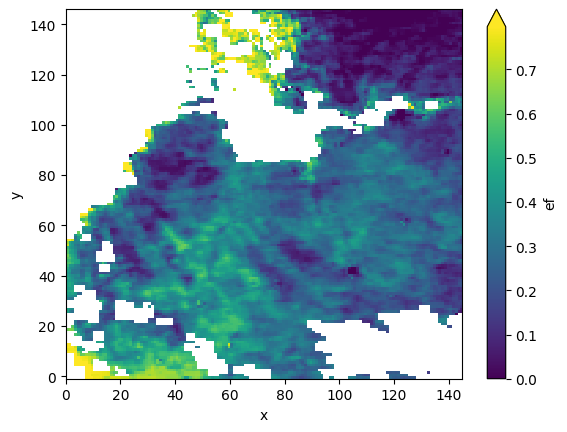

In [12]:
plot_band(res,band="ef")

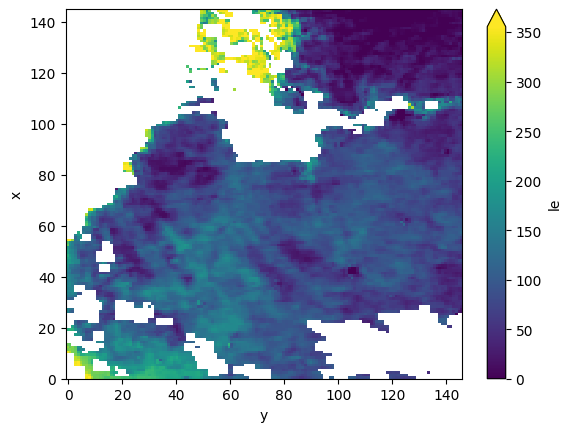

In [13]:
plot_band(res,band="le")

## Case: Detailed configuration

#### Configuration

In [14]:
config_dict = {
    "input": {
        "path": "../tests/data/modis_test.tif"
    },
    "output": {"path": "out"},
    "params": {
        "filtering": {},
        "ef": {
            "check": {"threshold": 0.02},
            "models": [
                {
                    "name": "model1",
                    "dry_edge": {
                        "type": "LinearEdge",
                        "config": {
                            "interval_type": "size",
                            "interval_nb": 20,
                            "percentile": [98, 100],
                            "selection": "median",
                        },
                    },
                    "wet_edge": {
                        "type": "LinearEdge",
                        "config": {
                            "interval_type": "size",
                            "interval_nb": 20,
                            "percentile": [0, 2],
                            "selection": "median",
                        },
                    },
                    "var": "albedo",
                },
                {
                    "name": "model2",
                    "dry_edge": {
                        "type": "LinearEdge",
                        "config": {
                            "interval_type": "density",
                            "interval_nb": 20,
                            "percentile": [95, 100],
                            "selection": "median",
                        },
                    },
                    "wet_edge": {"type": "FlatEdge", "config": {"selection": "min"}},
                    "var": "lai",
                },
            ],
            "options": {"selection": False, "merging": "mean"},
        },
    },
}

In [15]:
pprint(config_dict,sort_dicts=False)

{'input': {'path': '../tests/data/modis_test.tif'},
 'output': {'path': 'out'},
 'params': {'filtering': {},
            'ef': {'check': {'threshold': 0.02},
                   'models': [{'name': 'model1',
                               'dry_edge': {'type': 'LinearEdge',
                                            'config': {'interval_type': 'size',
                                                       'interval_nb': 20,
                                                       'percentile': [98, 100],
                                                       'selection': 'median'}},
                               'wet_edge': {'type': 'LinearEdge',
                                            'config': {'interval_type': 'size',
                                                       'interval_nb': 20,
                                                       'percentile': [0, 2],
                                                       'selection': 'median'}},
                               'var'

#### Execution

In [16]:
config = check_config(config_dict)

In [17]:
res = run_evaspa(config["input"], config["params"])

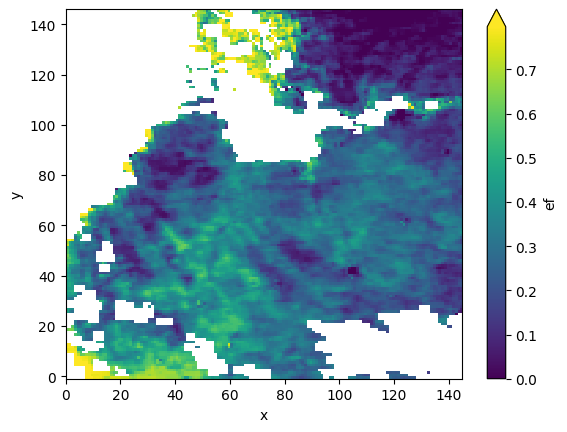

In [18]:
plot_band(res,band="ef")